# 03 · Ingeniería de variables

**Objetivo.** Construir un conjunto de variables sólido, justificado desde la perspectiva futbolística y estadística, y dejar la matriz de diseño lista para el modelado, **evitando fuga de información**.

Familias de variables (ver `src.features`):
1. **Geométricas**: distancia y ángulo a portería (las más informativas).
2. **Derivadas/no lineales**: log-distancia, inversa, interacción ángulo×distancia.
3. **Contextuales**: parte del cuerpo, tipo de disparo, patrón de juego, presión, primer toque, asistencia, *game state* (marcador).
4. **Defensivas/espaciales**: defensores en el cono, defensores cercanos, distancia al defensor más próximo, posición del portero (del *freeze frame*).

In [1]:
# Bootstrap: hace importable el paquete `xg` desde notebooks/ (src layout)
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == 'notebooks') else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from xg import config, features, models, analysis, visualization
from xg import data as data_loader
from xg.models import evaluation, statistics
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
config.ensure_dirs()
np.random.seed(config.RANDOM_STATE)
print('Proyecto:', config.PROJECT_ROOT.name)

Proyecto: TFM_xG_MachineLearning


In [2]:
raw, source = data_loader.build_shots_dataframe(source='auto')
feat = features.engineer_features(raw)
print('Variables creadas:', feat.shape[1])
feat[config.NUMERIC_FEATURES].describe().T

Variables creadas: 36


## 3.1 Construcción paso a paso (transparencia)
Las funciones son puras y componibles, lo que facilita auditar cada bloque.

In [3]:
g = features.add_geometric_features(raw)
d = features.add_derived_features(g)
c = features.add_context_features(d)
c[['x','y','distance_to_goal','shot_angle','log_distance',
   'inverse_distance','angle_distance_interaction','goal_diff','game_state']].head()

## 3.2 Justificación de la variable *ángulo*
El ángulo subtendido por los postes mide cuánta portería 've' el tirador. Dos disparos a la misma distancia pero distinto ángulo tienen probabilidades muy distintas; por eso el ángulo es complementario a la distancia.

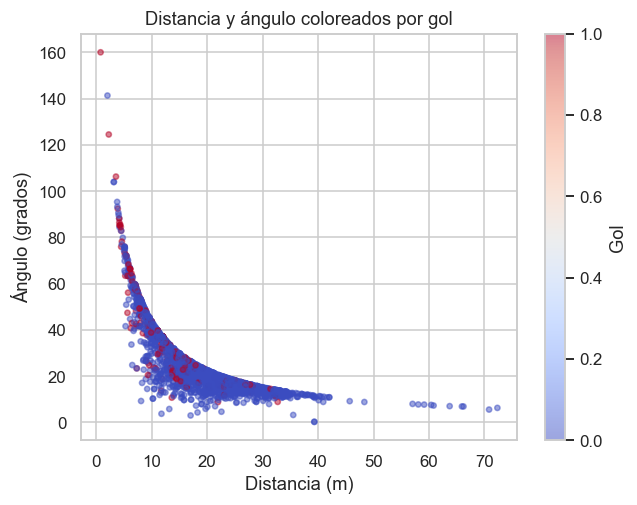

In [4]:
import numpy as np
sample = feat.sample(min(2000, len(feat)), random_state=config.RANDOM_STATE)
sc = plt.scatter(sample['distance_to_goal'], np.degrees(sample['shot_angle']),
    c=sample['is_goal'], cmap='coolwarm', alpha=0.5, s=12)
plt.xlabel('Distancia (m)'); plt.ylabel('Ángulo (grados)')
plt.colorbar(sc, label='Gol'); plt.title('Distancia y ángulo coloreados por gol'); plt.show()

## 3.3 Separación X / y y control de fuga de información
* Se **excluyen los penaltis** del modelo principal: su xG es casi constante (~0.76) e independiente de la geometría.
* La variable `statsbomb_xg` (si existe) **nunca** entra como predictor: sería fuga directa del objetivo.
* La imputación/escala/OHE se ajustan **dentro del Pipeline** (Notebook 04), solo con el train de cada fold.

In [5]:
X, y = features.split_features_target(feat, drop_penalties=True)
print('X:', X.shape, '| y tasa de gol:', round(y.mean(),4))
print('Numéricas:', len(config.NUMERIC_FEATURES), '| Categóricas:', len(config.CATEGORICAL_FEATURES))
# Guardado oficial: run_pipeline.py

X: (5606, 23) | y tasa de gol: 0.0904
Numéricas: 15 | Categóricas: 8


**Conclusión.** Matriz de diseño construida y justificada, con salvaguardas explícitas contra el *data leakage*. Lista para el modelado.